In [23]:

%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


# setting env.

In [24]:

from docutils.nodes import target
from scipy.stats import lognorm
from statsmodels.iolib.summary import summary

import os
from pathlib import Path
from unicodedata import category

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.font_manager import fontManager
import seaborn as sns
import duckdb
import statistics
import pandas as pd
import numpy as np
import functools
from IPython.core.pylabtools import figsize
from matplotlib.lines import lineStyles
from matplotlib.pyplot import xlabel, tight_layout
import os
import statsmodels.formula.api as smf

In [25]:
fontManager.get_font_names()

['Noto Sans Inscriptional Parthian',
 'Noto Sans Old Persian',
 'Malayalam MN',
 'Toppan Bunkyu Gothic',
 'October Compressed Tamil',
 'American Typewriter',
 'Apple Chancery',
 'Al Bayan',
 'Toppan Bunkyu Midashi Mincho',
 'Noto Sans Duployan',
 'Copperplate',
 'Academy Engraved LET',
 'Khmer MN',
 'Mukta Malar',
 'Noto Sans Marchen',
 'K2D',
 'System Font',
 'cmtt10',
 'STIX Two Text',
 'DIN Alternate',
 'KufiStandardGK',
 'Didot',
 'ITF Devanagari',
 'Arima Madurai',
 'Sinhala MN',
 'October Tamil',
 'Devanagari MT',
 'Noteworthy',
 'Noto Sans Hanifi Rohingya',
 'Euphemia UCAS',
 'Noto Sans Chakma',
 'Oriya Sangam MN',
 'Wingdings 2',
 'InaiMathi',
 'Noto Sans Thaana',
 'Big Caslon',
 '.SF Arabic Rounded',
 'Charmonman',
 'Diwan Kufi',
 'Sana',
 'Sama Tamil',
 'Noto Sans Masaram Gondi',
 'Tsukushi B Round Gothic',
 'Noto Sans Myanmar',
 'LiHei Pro',
 '.SF Armenian',
 'Hubballi',
 'Noto Sans Khojki',
 'Nanum Myeongjo',
 'Kohinoor Devanagari',
 'LiSong Pro',
 'DejaVu Serif Display',
 

In [55]:
import matplotlib
from matplotlib.font_manager import fontManager
matplotlib.rc('font',family = ['Times New Roman','Apple LiGothic'])

group_translate = {
    -1:'Group -1 (not in experiment)',
    0:'Group 0 (random)',
    1:'Group 1 (easy)',
    2:'Group 2 (easy to hard)',
    3:'Group 3 (hard to easy)'
}

# import data

In [27]:

os.getcwd()
df_question = pd.read_parquet("../data/raw/experiment-2025-q1/ntuecon_experiment_250525/question_structure.parquet")

#conn = duckdb.connect("./data/raw/experiment-2025-q1/ntuecon_experiment_250525/target_book_volume_log.parquet")
df_book_vol = pd.read_parquet(
    "../data/raw/experiment-2025-q1/ntuecon_experiment_250603/target_book_volume_log_2025-06-03.parquet")

#conn = duckdb.connect("./data/raw/experiment-2025-q1/ntuecon_experiment_250525/target_user_answer_log.parquet")
df_user_ans = pd.read_parquet(
    "../data/raw/experiment-2025-q1/ntuecon_experiment_250603/target_user_answer_log_2025-06-03.parquet")

#conn = duckdb.connect("./data/raw/experiment-2025-q1/ntuecon_experiment_250525/target_user_info.parquet")
df_user_info = pd.read_parquet(
    "../data/raw/experiment-2025-q1/ntuecon_experiment_250603/target_user_info_2025-06-03.parquet")

df_question = pd.read_parquet(
    "../data/raw/experiment-2025-q1/ntuecon_experiment_250525/question_structure.parquet")
df_user_ans_05 = pd.read_parquet(
    "../data/raw/experiment-2025-q1/ntuecon_experiment_250525/target_user_answer_log.parquet")
df_user_info_05 = pd.read_parquet(
    '../data/raw/experiment-2025-q1/ntuecon_experiment_250603/target_user_answer_log_2025-06-03.parquet')
daily_stat = pd.read_parquet(
    '../data/raw/experiment-2025-q1/ntuecon_experiment_250603/target_gc_daily_stat_2025-06-03.parquet')
course = pd.read_parquet(
    "../data/raw/experiment-2025-q1/ntuecon_experiment_250603/target_gc_course_2025-06-03.parquet")

In [28]:
df_question

,answer,status,difficulty_level,publisher,subject_name,book_volume_name,book_volume_year,book_volume_semester,book_volume_grade,section_name,book_volume_id,question_id,section_id
0,"[""B""]",deleted,1,康軒國小,None,None,None,<NA>,<NA>,None,<NA>,-6405624640022549461,<NA>
1,"[""C""]",deleted,1,康軒國小,None,None,None,<NA>,<NA>,None,<NA>,-3028868083937169421,<NA>
2,"[""A""]",deleted,2,康軒國小,None,None,None,<NA>,<NA>,None,<NA>,-8227513203886414362,<NA>
3,"[""C""]",deleted,2,康軒國小,None,None,None,<NA>,<NA>,None,<NA>,-6238923863858885195,<NA>
4,"[""B""]",deleted,3,康軒國小,None,None,None,<NA>,<NA>,None,<NA>,3299916324537394474,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1306424,"[""A""]",released,3,康軒國小,國語,四上113,113,0,<NA>,10 奇幻旋律,-7933997964409526370,3813914640257517845,-5909358065647070863
1306425,"[""A""]",released,1,康軒國中,社會,一上 113,113,0,7,06.社區與部落,-7177646212519467431,-7526009218465305760,-8720079213887773718
1306426,"[""A""]",released,2,康軒國中,社會,一上 113,113,0,7,06.社區與部落,-7177646212519467431,-511847278423702124,-8720079213887773718
1306427,"[""A""]",released,1,康軒國小,數學,四下113,113,0,<NA>,3 概數,-8538342032344072608,3053747046658221703,-7309289670126621399


In [29]:
df_book_vol

,id,user_id,gamecharacter_id,question_id,section_id,experiment_index,is_correct,created_at_utc8
0,-9053486455629282188,-1873430623263824362,-3402899112114895338,-5263639425820740356,-247801341597882458,0,0,2025-05-29 06:52:22
1,-628638455526084906,2539810456371290704,-5249020576050934100,-1897899015581030178,-247801341597882458,3,0,2025-05-29 07:08:37
2,5423695897606456782,4482546256344472469,-2519851847852223272,-3286862775113972652,-247801341597882458,1,1,2025-05-29 07:45:25
3,1009007262984326475,-1873430623263824362,-3402899112114895338,7246391716930387719,-247801341597882458,0,1,2025-05-29 06:49:05
4,8064186596603043880,4482546256344472469,-2519851847852223272,-5263639425820740356,-247801341597882458,1,0,2025-05-29 07:46:38
...,...,...,...,...,...,...,...,...
246202,1201833934479361621,6734848257007407643,-2380458800220678416,4640276776666593089,7685579370828672563,1,1,2025-05-06 14:03:10
246203,-8993535108970590512,6734848257007407643,-2380458800220678416,-4699624724852261829,7685579370828672563,1,0,2025-05-06 22:13:41
246204,-8547902248052557073,6734848257007407643,-2380458800220678416,-6428332898488313044,7685579370828672563,1,0,2025-05-06 14:09:31
246205,-1488249688878383059,8871704772713769416,7551657636002764410,689176003033462362,7685579370828672563,3,0,2025-05-06 12:29:17


In [30]:
testdff = pd.read_json("../data/processed/session_data_new.json")
testdff.info()
testdff['is_homo'] = testdff.section_id.apply(lambda x: all(xi == x[0] for xi in x))
testdff.head()


<class 'pandas.core.frame.DataFrame'>
Index: 36032 entries, (-9216223767477519093, -3293706459053707777, 1) to (9223087356083948458, 8730877631531542123, 1)
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   user_id               36032 non-null  int64         
 1   gamecharacter_id      36032 non-null  int64         
 2   session_id            36032 non-null  int64         
 3   is_correct            36032 non-null  object        
 4   difficulty_level      36032 non-null  object        
 5   experiment_index      36032 non-null  object        
 6   question_id           36032 non-null  object        
 7   subject_name          36032 non-null  object        
 8   section_id            36032 non-null  object        
 9   section_name          36032 non-null  object        
 10  school_city           36032 non-null  object        
 11  created_at            36032 non-null  object       

,user_id,gamecharacter_id,session_id,is_correct,difficulty_level,experiment_index,question_id,subject_name,section_id,section_name,...,time_diff,created_at_utc8,start_time,end_time,session_length,answer_length,experiment_mode,manual_book_vol_mode,subject_name_mode,is_homo
"(-9216223767477519093, -3293706459053707777, 1)",-9216223767477519093,-3293706459053707777,1,"[0, 0, 1, 0]","[1, 3, 3, 3]","[None, None, None, None]","[941132157500741589, -2528918832815624142, 603...","[數學, 數學, 數學, 數學]","[6084119510007883763, 6084119510007883763, 522...","[4 小數的乘法, 4 小數的乘法, 2 分數的計算, 2 分數的計算]",...,"[None, 19.0, 84.0, 30.0]","[1742298161000, 1742298180000, 1742298264000, ...",2025-03-18 11:42:41,2025-03-18 11:44:54,133,4,NaN,5,數學,False
"(-9215975131138636025, 2806305522055252713, 1)",-9215975131138636025,2806305522055252713,1,"[1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, ...","[1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 2, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[5986642740406154097, -1814475752912975980, 57...","[數學, 數學, 數學, 數學, 數學, 數學, 數學, 數學, 數學, 數學, 數學, 數...","[-247801341597882458, -247801341597882458, -24...","[1 體積, 1 體積, 1 體積, 1 體積, 1 體積, 1 體積, 1 體積, 1 體...",...,"[None, 102.0, 55.0, 13.0, 10.0, 16.0, 120.0, 1...","[1744596091000, 1744596193000, 1744596248000, ...",2025-04-14 02:01:31,2025-04-14 02:20:41,1150,35,1.0,5,數學,False
"(-9212166316050044816, 5893252723684985621, 1)",-9212166316050044816,5893252723684985621,1,"[1, 0, 1, 0, 1]","[1, 1, 2, 2, 1]","[None, None, None, None, None]","[-3982380057634078317, 6534779973756457463, -8...","[數學, 數學, 數學, 數學, 數學]","[-5730797827999106544, -1882325247118400549, 7...","[8-1 平行四邊形的面積, 9-1 分數表示整數相除的結果, 10-3 幾分之幾圖, 7-...",...,"[None, 13.0, 58.0, 40.0, 1580.0]","[1744897914000, 1744897927000, 1744897985000, ...",2025-04-17 13:51:54,2025-04-17 14:20:05,1691,5,NaN,5,數學,False
"(-9212166316050044816, 5893252723684985621, 2)",-9212166316050044816,5893252723684985621,2,"[1, 1, 1, 1, 1, 1, 1]","[1, 2, 2, 2, 2, 1, 1]","[3, 3, 3, 3, 3, 3, 3]","[5986642740406154097, -1814475752912975980, 48...","[數學, 數學, 數學, 數學, 數學, 數學, 數學]","[-247801341597882458, -247801341597882458, -24...","[1 體積, 1 體積, 1 體積, 1 體積, 1 體積, 1 體積, 1 體積]",...,"[1940.0, 93.0, 60.0, 93.0, 33.0, 14.0, 41.0]","[1744901545000, 1744901638000, 1744901698000, ...",2025-04-17 14:52:25,2025-04-17 14:57:59,334,7,3.0,5,數學,True
"(-9188432125589223658, -3468651825129845530, 1)",-9188432125589223658,-3468651825129845530,1,"[0, 0]","[2, 1]","[None, None]","[-8645121234103906346, 6775587959579167004]","[數學, 數學]","[1466806251755821696, 1466806251755821696]","[8 分數, 8 分數]",...,"[None, 6.0]","[1744018600000, 1744018606000]",2025-04-07 09:36:40,2025-04-07 09:36:46,6,2,NaN,4,數學,True


# Separate sessions by sections(章節)


In [61]:
# trasform data to seperate different character
long_data = pd.DataFrame()
diff_list = []
corr_list = []
question_list = []
user_id = []
session_id = []
gamecharacter_id = []
section_id = []
experiment_index = []
experiment_mode = []
create_time = []

for idx, row in testdff.iterrows():
    section_set = list(set(row.section_id))
    for sec in section_set:
        section_id.append(sec)
        user_id.append(row.user_id)
        session_id.append(row.session_id)
        gamecharacter_id.append(row.gamecharacter_id)
        experiment_mode.append(row.experiment_mode)
        experiment_index.append([row.experiment_index[idx] for idx, x in enumerate(row.section_id) if x == sec])
        diff_list.append([row.difficulty_level[idx] for idx, x in enumerate(row.section_id) if x == sec])
        corr_list.append([row.is_correct[idx] for idx, x in enumerate(row.section_id) if x == sec])
        question_list.append([row.question_id[idx] for idx, x in enumerate(row.section_id) if x == sec])
        create_time.append([pd.to_datetime(row.created_at_utc8[idx],unit='ms')  for idx, x in enumerate(row.section_id) if x == sec])

long_data['user_id'] = user_id
long_data['session_id'] = session_id
long_data['gamecharacter_id'] = gamecharacter_id
long_data['section_id'] = section_id
long_data['difficulty_level'] = diff_list
long_data['is_correct'] = corr_list
long_data['question_id'] = question_list
long_data['experiment_index'] = experiment_index
long_data['experiment_mode'] = experiment_mode
long_data['create_time'] = create_time



In [62]:
long_data['experiment_mode'] = long_data['experiment_mode'].fillna(-1)
#long_data = long_data.drop_duplicates(subset=['section_id','user_id','gamecharacter_id'])
long_data.to_json('../data/processed/session_by_section_data_new.json')
long_data.value_counts('experiment_mode')
long_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83823 entries, 0 to 83822
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           83823 non-null  int64  
 1   session_id        83823 non-null  int64  
 2   gamecharacter_id  83823 non-null  int64  
 3   section_id        83823 non-null  int64  
 4   difficulty_level  83823 non-null  object 
 5   is_correct        83823 non-null  object 
 6   question_id       83823 non-null  object 
 7   experiment_index  83823 non-null  object 
 8   experiment_mode   83823 non-null  float64
 9   create_time       83823 non-null  object 
dtypes: float64(1), int64(4), object(5)
memory usage: 6.4+ MB


In [63]:
long_data['start at'] = long_data.create_time.map(lambda lis: min(lis))
long_data['end at'] = long_data.create_time.map(lambda lis: max(lis))
long_data['average correct rate'] = long_data.is_correct.map(lambda lis: np.mean(lis))
long_data['question length'] = long_data.is_correct.apply(lambda x : len(x))
long_data['time cost'] = long_data.apply(lambda row : row['end at'] - row['start at'],axis=1)
long_data['experiment_mode'] = long_data['experiment_mode'].astype('category')

long_data.head()

,user_id,session_id,gamecharacter_id,section_id,difficulty_level,is_correct,question_id,experiment_index,experiment_mode,create_time,start at,end at,average correct rate,question length,time cost
0,-9216223767477519093,1,-3293706459053707777,5223737939809232457,"[3, 3]","[1, 0]","[603844519309736809, 6790652223673883887]","[None, None]",-1.0,"[2025-03-18 11:44:24, 2025-03-18 11:44:54]",2025-03-18 11:44:24,2025-03-18 11:44:54,0.500000,2,0 days 00:00:30
1,-9216223767477519093,1,-3293706459053707777,6084119510007883763,"[1, 3]","[0, 0]","[941132157500741589, -2528918832815624142]","[None, None]",-1.0,"[2025-03-18 11:42:41, 2025-03-18 11:43:00]",2025-03-18 11:42:41,2025-03-18 11:43:00,0.000000,2,0 days 00:00:19
2,-9215975131138636025,1,2806305522055252713,-9042528178512436726,"[1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2]","[1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1]","[4680614589130178593, -1794677401750382001, -1...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",1.0,"[2025-04-14 02:15:35, 2025-04-14 02:16:33, 202...",2025-04-14 02:15:35,2025-04-14 02:20:41,0.833333,12,0 days 00:05:06
3,-9215975131138636025,1,2806305522055252713,-247801341597882458,"[1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 2]","[1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0]","[5986642740406154097, -1814475752912975980, 57...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",1.0,"[2025-04-14 02:01:31, 2025-04-14 02:03:13, 202...",2025-04-14 02:01:31,2025-04-14 02:10:59,0.545455,11,0 days 00:09:28
4,-9215975131138636025,1,2806305522055252713,145845299402454255,"[1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2]","[0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0]","[69113588992878618, -75308616834142435, -23488...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",1.0,"[2025-04-14 02:11:22, 2025-04-14 02:11:51, 202...",2025-04-14 02:11:22,2025-04-14 02:15:19,0.416667,12,0 days 00:03:57


In [64]:


long_data['q_len'] = long_data.is_correct.apply(lambda x: len(x))
#long_data = long_data.query('session_id == 1')
long_data['experiment_mode'] = long_data['experiment_mode'].fillna(-1)
long_data.groupby('experiment_mode').describe()
long_data['create_at'] = long_data.create_time.apply(lambda x : x[0])
#long_data = long_data.query('create_at >= "2025-04-08"')

rawdata = long_data.copy()
rawdata.value_counts('experiment_mode')

/var/folders/n9/jhsz5r6d6cvctky31mq3pnfr0000gn/T/ipykernel_5490/1111772469.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  long_data.groupby('experiment_mode').describe()


experiment_mode
-1.0    53918
 1.0     7987
 0.0     7878
 2.0     7313
 3.0     6727
Name: count, dtype: int64

In [65]:

long_data = long_data.query('q_len >= 12')
rawdata.value_counts('experiment_mode')
long_data.value_counts('experiment_mode')

experiment_mode
-1.0    8912
 1.0    1997
 0.0    1973
 2.0    1888
 3.0    1752
Name: count, dtype: int64

``` python
def difficulty_proportions(series_lists, levels=(1, 2, 3), n_questions=12):
    """
    series_lists: pandas Series，每個元素是一個 difficulty_level 的 list
    回傳：一個 dict，key 為難度等級，value 為長度 n_questions 的比例陣列
    """
    # 建立矩陣 (num_samples, n_questions)
    matrix = np.array([lst[:n_questions] for lst in series_lists], dtype=float)
    # 每題非 nan 的樣本數
    valid_counts = np.sum(~np.isnan(matrix), axis=0)
    props = {}
    for lvl in levels:
        # 計算該等級出現次數，再除以 valid_counts
        props[lvl] = np.sum(matrix == lvl, axis=0) / valid_counts
    return props


# 1. 計算每組的難度分佈比例
grouped = long_data.groupby('experiment_mode')['difficulty_level']
diff_props = {
    mode: difficulty_proportions(series)
    for mode, series in grouped
}

# 2. 畫圖：3x2 子圖，每組一張堆疊長條圖
fig, axs = plt.subplots(3, 2, figsize=(12, 8), sharex=True, sharey=True)
axs = axs.flatten()
x = np.arange(1, 13)  # 題號 1–12
levels = (1, 2, 3)

for i, (mode, props) in enumerate(diff_props.items()):
    ax = axs[i]
    bottom = np.zeros_like(x, dtype=float)
    for lvl in levels:
        ax.bar(x, props[lvl], bottom=bottom, label=f'Level {lvl}')
        bottom += props[lvl]
    ax.set_title(f'Group {mode}')
    ax.set_xticks(x)
    ax.set_xlabel('Question Number')
    ax.set_ylabel('Proportion')
    ax.set_ylim(0, 1)
    ax.grid(True)

# 第 1 個子圖加圖例


ax.legend(bbox_to_anchor=(-1, -0.5, 2.1, 2), loc='lower right', ncol=3, mode="expand", borderaxespad=0.)
plt.tight_layout()
plt.show()

```

In [66]:

for qid in range(12):
    long_data[f'q_{qid + 1}'] = long_data['question_id'].apply(lambda x: x[qid])
    long_data[f'q_{qid + 1}_corr'] = long_data['is_correct'].apply(lambda x: x[qid])

for i in [-1, 0, 1, 2, 3]:
    for qid in range(12):
        print(long_data[long_data['experiment_mode'] == i][f'q_{qid + 1}'].mode(dropna=True))
        long_data[f'q_{qid + 1}_mode'] = long_data[long_data['experiment_mode'] == i][f'q_{qid + 1}'].mode(dropna=True)[
            0]

long_data['all_mode'] = True

for qid in [0, 1, 5, 9, 10, 11]:
    mask = long_data[f'q_{qid + 1}'] == long_data[f'q_{qid + 1}_mode']
    long_data['all_mode'] &= mask

0    4991778149722867127
Name: q_1, dtype: int64
0    5786121490234329394
Name: q_2, dtype: int64
0   -1783125651226257124
1     831253084160088526
Name: q_3, dtype: int64
0    5556066601331488933
Name: q_4, dtype: int64
0   -5531336178737327718
Name: q_5, dtype: int64
0    4252998108459867338
Name: q_6, dtype: int64
0    4991778149722867127
Name: q_7, dtype: int64
0    8707461698589525409
Name: q_8, dtype: int64
0    4991778149722867127
Name: q_9, dtype: int64
0    8231509399365486276
Name: q_10, dtype: int64
0    5786121490234329394
Name: q_11, dtype: int64
0    831253084160088526
Name: q_12, dtype: int64
0    5986642740406154097
Name: q_1, dtype: int64
0   -1814475752912975980
Name: q_2, dtype: int64
0    5786121490234329394
Name: q_3, dtype: int64
0   -1025311054463154271
Name: q_4, dtype: int64
0    7479955377401805758
Name: q_5, dtype: int64
0    7041016536148449936
Name: q_6, dtype: int64
0    4816520945223989067
Name: q_7, dtype: int64
0    7246391716930387719
Name: q_8, dtype:

``` python
# did analyze on q1 to q10 and q2 to q11, q12
import statsmodels.formula as fml
import statsmodels.formula.api as smf


def did_analyze(df: pd.DataFrame, baseline: int, target: list):
    recode_dict = {f'q_{target[0]}_corr': 0, f'q_{target[1]}_corr': 1}
    df = df.melt(id_vars=['user_id', 'section_id', 'experiment_mode'],
                 value_vars=[f'q_{target[0]}_corr', f'q_{target[1]}_corr'],
                 var_name='time_binary',
                 value_name='corr'
                 )
    df['time_binary'] = df['time_binary'].apply(lambda x: recode_dict[x])
    formula = (
        f'corr ~ time_binary * '
        f'C(experiment_mode, Treatment(reference={baseline}))'
    )
    model = smf.ols(formula, data=df).fit()
    print(model.summary())

    return model


model = did_analyze(long_data.query('all_mode == True'), baseline=1, target=[1, 10])
```

``` python
target = [3, 11]
summary_df = (
    long_data.query('all_mode == True')
    .groupby('experiment_mode')
    .agg(
        mean_pre=(f'q_{target[0]}_corr', 'mean'),
        mean_post=(f'q_{target[1]}_corr', 'mean'),
        std_pre=(f'q_{target[0]}_corr', 'std'),
        std_post=(f'q_{target[1]}_corr', 'std')
    )
    .reset_index()
)

df_plot = summary_df.melt(
    id_vars='experiment_mode',
    value_vars=['mean_pre', 'mean_post'],
    var_name='time_point',
    value_name='mean_score'
)

# 畫 grouped bar chart
plt.figure(figsize=(9, 6))

# 畫圖時以 experiment_mode 為 x 軸，time_point 為 hue（也就是 pre/post）
import seaborn as sns

sns.barplot(
    data=df_plot,
    x='experiment_mode',
    y='mean_score',
    hue='time_point',
    palette='Set2'
)

plt.title("Mean Score (Pre/Post) by Experiment Mode")
plt.xlabel("Experiment Mode")
plt.ylabel("Mean Score")
plt.ylim(0, 1)  # 根據你的 mean 值調整
plt.legend(title='Time Point')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
```

# filter session by question id

In [67]:
# import control sequences

control_seqs = pd.read_csv('../data/raw/question_sequence.csv')

recode_dict = {
    'control':0,
    'treatment1':1,
    'treatment2':2,
    'treatment3':3,
    }

section_dict = dict(zip(df_question.section_name,df_question.section_id))
rev_section_dict = dict(zip(df_question.section_id,df_question.section_name))

control_seqs['section_id'] = control_seqs.section_name_113_2.map(section_dict)
control_seqs['experiment_mode'] = control_seqs.sequence.map(recode_dict)
control_seqs['search_key'] = control_seqs.apply(lambda row: str(row['section_id'])+'_'+ str(row['experiment_mode']),axis = 1)
control_seqs['control_seq'] = control_seqs.apply(lambda row:np.array([row[f'Q{i+1}'] for i in range(12)]),axis = 1)


In [68]:
control_seqs.head()

,Unnamed: 0,sequence,publisher,section_name,book_volume_name,publisher_name_113_2,section_name_113_2,book_volume_name_113_2,Q1,Q2,...,Q7,Q8,Q9,Q10,Q11,Q12,section_id,experiment_mode,search_key,control_seq
0,0,control,康軒國小,3 容積,五下112,康軒國小,3 容積,五下113,69113588992878618,-75308616834142435,...,-1908360932417219092,-2348804092072956357,4649250512404957905,5948577754904052468,-4358907609513604648,-7361052562344121223,-3545039493898610459,0,-3545039493898610459_0,"[69113588992878618, -75308616834142435, -53711..."
1,1,treatment1,康軒國小,3 容積,五下112,康軒國小,3 容積,五下113,69113588992878618,-75308616834142435,...,4334620487126035177,5108527915460688310,-1288720951380365417,5948577754904052468,-4358907609513604648,-7361052562344121223,-3545039493898610459,1,-3545039493898610459_1,"[69113588992878618, -75308616834142435, -23488..."
2,2,treatment2,康軒國小,3 容積,五下112,康軒國小,3 容積,五下113,69113588992878618,-75308616834142435,...,-3202230148646485972,-1908360932417219092,-8594155001789108421,5948577754904052468,-4358907609513604648,-7361052562344121223,-3545039493898610459,2,-3545039493898610459_2,"[69113588992878618, -75308616834142435, -23488..."
3,3,treatment3,康軒國小,3 容積,五下112,康軒國小,3 容積,五下113,69113588992878618,-75308616834142435,...,-2348804092072956357,-5371107019222777434,4649250512404957905,5948577754904052468,-4358907609513604648,-7361052562344121223,-3545039493898610459,3,-3545039493898610459_3,"[69113588992878618, -75308616834142435, -32022..."
4,0,control,康軒國小,9 時間的乘除,五下112,康軒國小,9 時間的乘除,五下113,520497830035904533,-2091250926218676150,...,-2307309825203258326,-4398838213214723618,4054464459422027015,2596504183669148612,3305360628776648069,-2670908083034426001,-3525338262485141936,0,-3525338262485141936_0,"[520497830035904533, -2091250926218676150, 174..."


In [69]:
experiment_data = long_data.query('experiment_mode != -1')
experiment_data.loc[:,'12_question_id'] = experiment_data['question_id'].apply(lambda x : x[:12])
experiment_data.loc[:,'search_key'] = experiment_data.apply(lambda row: str(row['section_id'])+'_'+ str(int(row['experiment_mode'])),axis = 1)

/var/folders/n9/jhsz5r6d6cvctky31mq3pnfr0000gn/T/ipykernel_5490/874510696.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  experiment_data.loc[:,'12_question_id'] = experiment_data['question_id'].apply(lambda x : x[:12])
/var/folders/n9/jhsz5r6d6cvctky31mq3pnfr0000gn/T/ipykernel_5490/874510696.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  experiment_data.loc[:,'search_key'] = experiment_data.apply(lambda row: str(row['section_id'])+'_'+ str(int(row['experiment_mode'])),axis = 1)


In [70]:

seq_dict = dict(zip(control_seqs.search_key,control_seqs.control_seq))



experiment_data['seq_valid'] = experiment_data.apply(lambda row:
                                                     np.array_equal(row['12_question_id'],seq_dict.get(row['search_key'])),axis = 1)
experiment_data['control_seq'] = experiment_data['search_key'].apply(lambda  skey:seq_dict.get(skey))


/var/folders/n9/jhsz5r6d6cvctky31mq3pnfr0000gn/T/ipykernel_5490/2871953063.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  experiment_data['seq_valid'] = experiment_data.apply(lambda row:
/var/folders/n9/jhsz5r6d6cvctky31mq3pnfr0000gn/T/ipykernel_5490/2871953063.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  experiment_data['control_seq'] = experiment_data['search_key'].apply(lambda  skey:seq_dict.get(skey))


In [71]:
experiment_data.create_time.apply(lambda x: x[0]).max()

Timestamp('2025-06-03 21:09:41')

In [72]:
# make new df
raw_experiment_data = rawdata.query('experiment_mode != -1')
raw_experiment_data.loc[:, '12_question_id'] = raw_experiment_data['question_id'].apply(lambda x: x[:12])
raw_experiment_data.loc[:, 'search_key'] = raw_experiment_data.apply(
    lambda row: str(row['section_id']) + '_' + str(int(row['experiment_mode'])), axis=1)

seq_dict = dict(zip(control_seqs.search_key, control_seqs.control_seq))

raw_experiment_data['seq_valid'] = raw_experiment_data.apply(lambda row:
                                                     np.array_equal(row['12_question_id'],
                                                                    seq_dict.get(row['search_key'])), axis=1)
raw_experiment_data['control_seq'] = raw_experiment_data['search_key'].apply(lambda skey: seq_dict.get(skey))

for qid in range(12):
    raw_experiment_data[f'q_{qid + 1}'] = raw_experiment_data['question_id'].apply(lambda x: x[qid] if qid < len(x) else None)
    raw_experiment_data[f'q_{qid + 1}_corr'] = raw_experiment_data['is_correct'].apply(lambda x: x[qid] if qid < len(x) else None)


def is_equal(l_lis,r_lis,q_len):
    if r_lis is None:
        return False
    itern = min(len(l_lis),q_len)
    for i in range(itern):
        if l_lis[i] != r_lis[i]:
            return False
    return True
for i in range(1,13):
    raw_experiment_data[f'seq_valid_less{i}inc'] = raw_experiment_data.apply(lambda row: is_equal(row['12_question_id'],row['control_seq'],i) ,axis = 1)


/var/folders/n9/jhsz5r6d6cvctky31mq3pnfr0000gn/T/ipykernel_5490/2167663836.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_experiment_data.loc[:, '12_question_id'] = raw_experiment_data['question_id'].apply(lambda x: x[:12])
/var/folders/n9/jhsz5r6d6cvctky31mq3pnfr0000gn/T/ipykernel_5490/2167663836.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_experiment_data.loc[:, 'search_key'] = raw_experiment_data.apply(
/var/folders/n9/jhsz5r6d6cvctky31mq3pnfr0000gn/T/ipykernel_5490/2167663836.py:9: S

In [73]:
raw_experiment_data.value_counts('experiment_mode')

experiment_mode
 1.0    7987
 0.0    7878
 2.0    7313
 3.0    6727
-1.0       0
Name: count, dtype: int64

In [74]:
print(rawdata.sort_values('create_at').drop_duplicates(subset=['user_id','gamecharacter_id','section_id']).value_counts('experiment_mode'))

experiment_mode
-1.0    23061
 1.0     3249
 0.0     3205
 2.0     3147
 3.0     2877
Name: count, dtype: int64


# Results

Text(0.5, 0, 'Question No.')

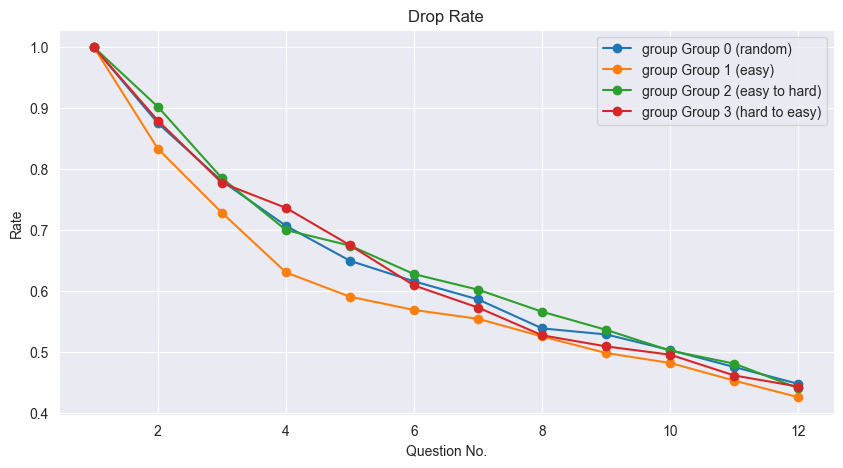

In [116]:
raw_experiment_data_f12corr = raw_experiment_data.query('seq_valid_less12inc == True').copy()
plt.figure(figsize=(10,5))
drop_rate_lis = []
for g in [0,1,2,3]:
    plt.plot([i+1 for i in range(12)],[len(raw_experiment_data_f12corr.query(f'q_len >= {i+1} and experiment_mode == {g}').index)/len(raw_experiment_data_f12corr.query(f'experiment_mode == {g}').index) for i in range(12)],label = f'group {group_translate[g]}',marker = 'o')
for q in [5,9,11]:
    raw_experiment_data_f12corr.loc[:,f'q{q+1}_exist'] = raw_experiment_data_f12corr.loc[:,'q_len'].apply(lambda x : x>q)
plt.legend()
plt.title('Drop Rate')
plt.ylabel('Rate')
plt.xlabel('Question No.')

In [117]:
raw_experiment_data_f12corr.columns

Index(['user_id', 'session_id', 'gamecharacter_id', 'section_id',
       'difficulty_level', 'is_correct', 'question_id', 'experiment_index',
       'experiment_mode', 'create_time', 'start at', 'end at',
       'average correct rate', 'question length', 'time cost', 'q_len',
       'create_at', '12_question_id', 'search_key', 'seq_valid', 'control_seq',
       'q_1', 'q_1_corr', 'q_2', 'q_2_corr', 'q_3', 'q_3_corr', 'q_4',
       'q_4_corr', 'q_5', 'q_5_corr', 'q_6', 'q_6_corr', 'q_7', 'q_7_corr',
       'q_8', 'q_8_corr', 'q_9', 'q_9_corr', 'q_10', 'q_10_corr', 'q_11',
       'q_11_corr', 'q_12', 'q_12_corr', 'seq_valid_less1inc',
       'seq_valid_less2inc', 'seq_valid_less3inc', 'seq_valid_less4inc',
       'seq_valid_less5inc', 'seq_valid_less6inc', 'seq_valid_less7inc',
       'seq_valid_less8inc', 'seq_valid_less9inc', 'seq_valid_less10inc',
       'seq_valid_less11inc', 'seq_valid_less12inc', 'q6_exist', 'q10_exist',
       'q12_exist'],
      dtype='object')

In [135]:
import pandas as pd
import statsmodels.formula.api as smf

y_cols = ['q6_exist', 'q10_exist', 'q12_exist']

# 取欄並複製
cols = ['experiment_mode', 'q_len'] + y_cols
df = raw_experiment_data_f12corr[raw_experiment_data_f12corr['experiment_mode'] != -1].loc[:, cols].copy()

print(df.value_counts('q6_exist'))


# 類型整理
df['experiment_mode'] = df['experiment_mode'].astype('category')
df['experiment_mode'] = df['experiment_mode'].cat.remove_unused_categories()
df['q_len'] = pd.to_numeric(df['q_len'], errors='coerce')

# 將布林/字串 True/False 轉為 0/1（再轉 float）
for y in y_cols:
    df[y] = (
        df[y]
        .replace({True: 1, False: 0, 'True': 1, 'False': 0})
        .astype(float)
    )

# 跑中位數回歸
for y in y_cols:
    dfi = df.dropna(subset=[y, 'experiment_mode'])
    if dfi.empty:
        print(f"[Skip] {y}: 無有效資料")
        continue
    fit = smf.ols(f"{y} ~ C(experiment_mode, Treatment(reference=1)) ", dfi).fit()
    print(f"\n=== {y} (ols Regression) ===")
    print(fit.summary())


q6_exist
True     1188
False     779
Name: count, dtype: int64

=== q6_exist (ols Regression) ===
                            OLS Regression Results                            
Dep. Variable:               q6_exist   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.432
Date:                Fri, 19 Sep 2025   Prob (F-statistic):              0.231
Time:                        11:10:14   Log-Likelihood:                -1382.0
No. Observations:                1967   AIC:                             2772.
Df Residuals:                    1963   BIC:                             2794.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                                        coef    std err          t      P>|t|      [0.025      0

/var/folders/n9/jhsz5r6d6cvctky31mq3pnfr0000gn/T/ipykernel_5490/1700400917.py:22: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({True: 1, False: 0, 'True': 1, 'False': 0})
/var/folders/n9/jhsz5r6d6cvctky31mq3pnfr0000gn/T/ipykernel_5490/1700400917.py:22: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({True: 1, False: 0, 'True': 1, 'False': 0})
/var/folders/n9/jhsz5r6d6cvctky31mq3pnfr0000gn/T/ipykernel_5490/1700400917.py:22: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a futu

In [76]:
valid_experiment_data = experiment_data.query('seq_valid == True')


In [77]:
valid_experiment_data.value_counts('experiment_mode')

experiment_mode
 1.0    235
 0.0    226
 2.0    207
 3.0    195
-1.0      0
Name: count, dtype: int64

In [78]:
raw_experiment_data.columns

Index(['user_id', 'session_id', 'gamecharacter_id', 'section_id',
       'difficulty_level', 'is_correct', 'question_id', 'experiment_index',
       'experiment_mode', 'create_time', 'start at', 'end at',
       'average correct rate', 'question length', 'time cost', 'q_len',
       'create_at', '12_question_id', 'search_key', 'seq_valid', 'control_seq',
       'q_1', 'q_1_corr', 'q_2', 'q_2_corr', 'q_3', 'q_3_corr', 'q_4',
       'q_4_corr', 'q_5', 'q_5_corr', 'q_6', 'q_6_corr', 'q_7', 'q_7_corr',
       'q_8', 'q_8_corr', 'q_9', 'q_9_corr', 'q_10', 'q_10_corr', 'q_11',
       'q_11_corr', 'q_12', 'q_12_corr', 'seq_valid_less1inc',
       'seq_valid_less2inc', 'seq_valid_less3inc', 'seq_valid_less4inc',
       'seq_valid_less5inc', 'seq_valid_less6inc', 'seq_valid_less7inc',
       'seq_valid_less8inc', 'seq_valid_less9inc', 'seq_valid_less10inc',
       'seq_valid_less11inc', 'seq_valid_less12inc'],
      dtype='object')

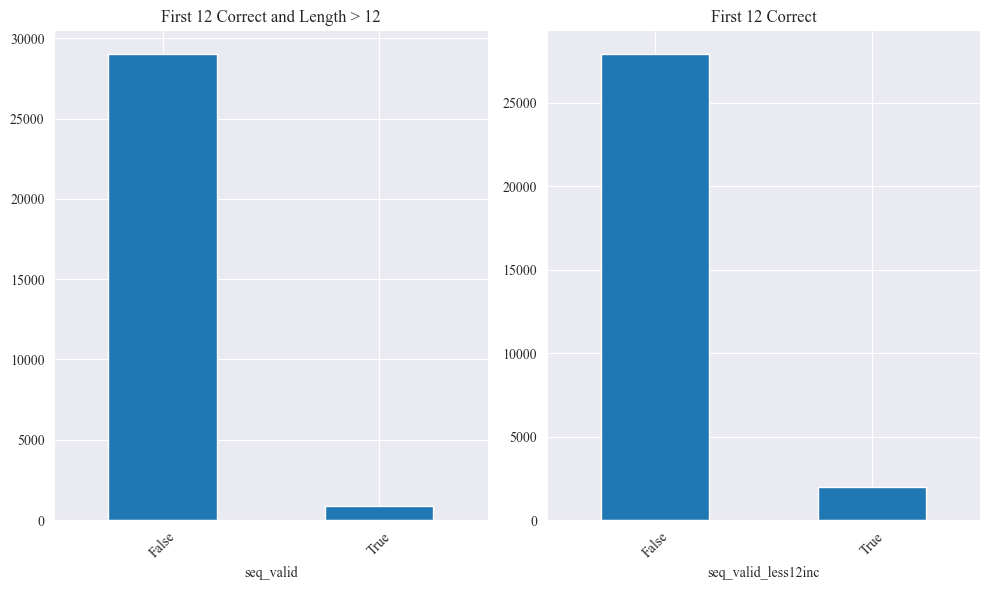


------------------- first 12 correct and question length > 12 ------------------
seq_valid
False    29042
True       863
Name: count, dtype: int64

------------------- first 12 correct ------------------
seq_valid_less12inc
False    27938
True      1967
Name: count, dtype: int64


In [79]:
# Plot value counts results
plt.figure(figsize=(10, 6))

# Plot seq_valid counts
plt.subplot(1, 2, 1)
seq_valid_counts = raw_experiment_data.value_counts('seq_valid')
seq_valid_counts.plot(kind='bar')
plt.title('First 12 Correct and Length > 12')
plt.xticks(rotation=45)

# Plot seq_valid_less12inc counts 
plt.subplot(1, 2, 2)
less12_counts = raw_experiment_data.value_counts('seq_valid_less12inc')
less12_counts.plot(kind='bar')
plt.title('First 12 Correct')
plt.xticks(rotation=45)



plt.tight_layout()
plt.show()

print("\n------------------- first 12 correct and question length > 12 ------------------")
print(raw_experiment_data.value_counts('seq_valid'))
print("\n------------------- first 12 correct ------------------")
print(raw_experiment_data.value_counts('seq_valid_less12inc'))



# make stack bar plot

/var/folders/n9/jhsz5r6d6cvctky31mq3pnfr0000gn/T/ipykernel_5490/2166779105.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = valid_experiment_data.groupby('experiment_mode')['difficulty_level']
/var/folders/n9/jhsz5r6d6cvctky31mq3pnfr0000gn/T/ipykernel_5490/2166779105.py:31: RuntimeWarning: invalid value encountered in scalar divide
  props[lvl] = np.sum(matrix == lvl, axis=0) / valid_counts


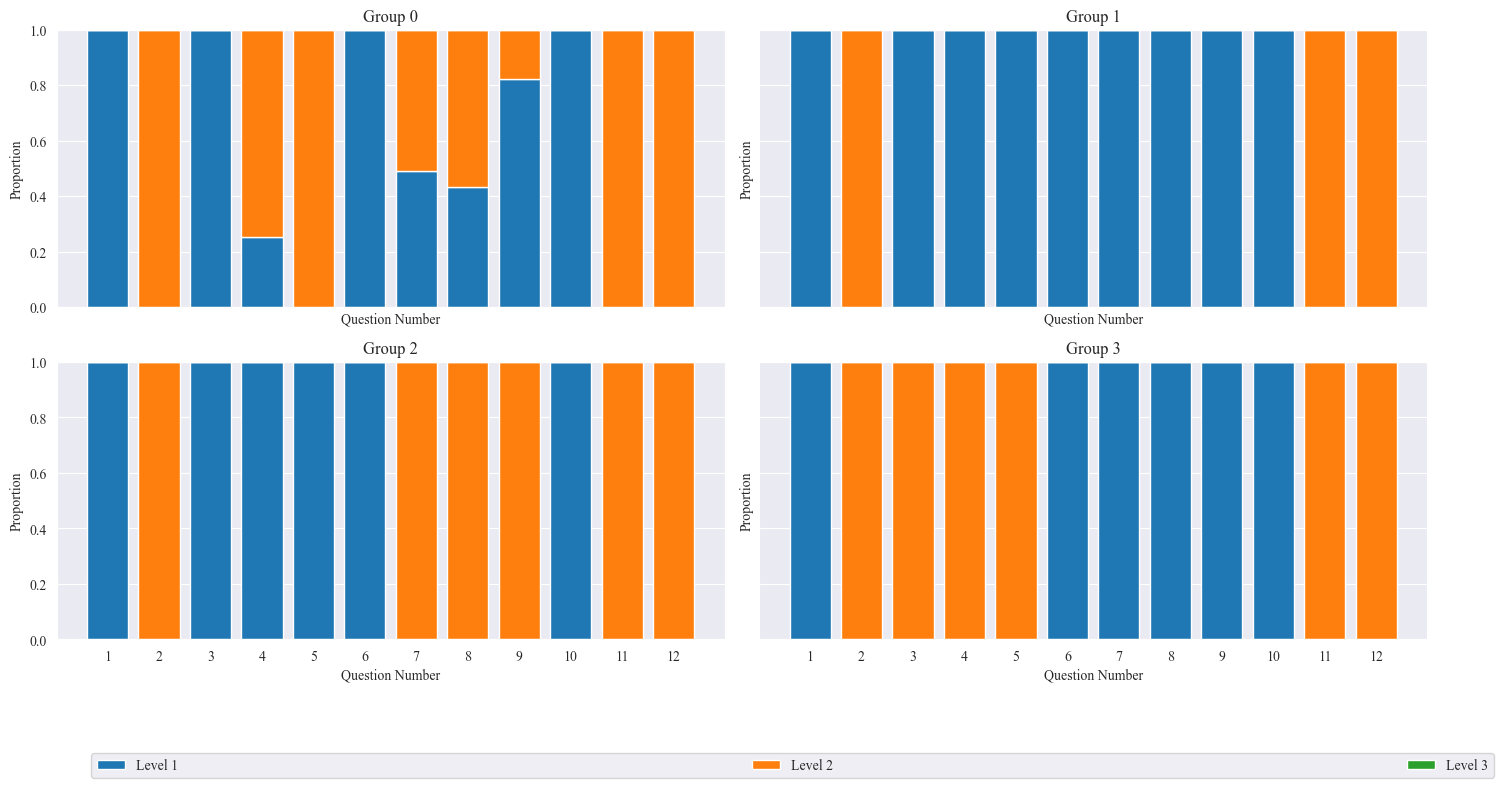

In [83]:

# 1. 計算每組的難度分佈比例
def did_analyze(df: pd.DataFrame, baseline: int, target: list):
    recode_dict = {f'q_{target[0]}_corr': 0, f'q_{target[1]}_corr': 1}
    df = df.melt(id_vars=['user_id', 'section_id', 'experiment_mode'],
                 value_vars=[f'q_{target[0]}_corr', f'q_{target[1]}_corr'],
                 var_name='time_binary',
                 value_name='corr'
                 )
    df['time_binary'] = df['time_binary'].apply(lambda x: recode_dict[x])
    formula = (
        f'corr ~ time_binary * '
        f'C(experiment_mode, Treatment(reference={baseline}))'
    )
    model = smf.ols(formula, data=df).fit()
    print(model.summary())

    return model

def difficulty_proportions(series_lists, levels=(1, 2, 3), n_questions=12):
    """
    series_lists: pandas Series，每個元素是一個 difficulty_level 的 list
    回傳：一個 dict，key 為難度等級，value 為長度 n_questions 的比例陣列
    """
    # 建立矩陣 (num_samples, n_questions)
    matrix = np.array([lst[:n_questions] for lst in series_lists], dtype=float)
    # 每題非 nan 的樣本數
    valid_counts = np.sum(~np.isnan(matrix), axis=0)
    props = {}
    for lvl in levels:
        # 計算該等級出現次數，再除以 valid_counts
        props[lvl] = np.sum(matrix == lvl, axis=0) / valid_counts
    return props



grouped = valid_experiment_data.groupby('experiment_mode')['difficulty_level']
diff_props = {
    mode: difficulty_proportions(series)
    for mode, series in grouped
}

# 2. 畫圖：3x2 子圖，每組一張堆疊長條圖
fig, axs = plt.subplots(2, 2, figsize=(15, 8), sharex=True, sharey=True)
axs = axs.flatten()
x = np.arange(1, 13)  # 題號 1–12
levels = (1, 2, 3)

for mode in  [0,1,2,3]:
    props = diff_props.get(mode)
    ax = axs[mode]
    bottom = np.zeros_like(x, dtype=float)
    for lvl in levels:
        ax.bar(x, props[lvl], bottom=bottom, label=f'Level {lvl}')
        bottom += props[lvl]
    ax.set_title(f'Group {int(mode)}')
    ax.set_xticks(x)
    ax.set_xlabel('Question Number')
    ax.set_ylabel('Proportion')
    ax.set_ylim(0, 1)
    ax.grid(True)

plt.legend(bbox_to_anchor=(-1, -0.5, 2.1, 2), loc='lower right', ncol=3, mode="expand", borderaxespad=0.)
plt.tight_layout()
plt.show()

# DID

In [84]:
# make long data to do did
valid_experiment_data_no0 = valid_experiment_data.query('experiment_mode != 0')
print('_________________________________________ q1 q10_________________________________________ \n')
did_1_10 = did_analyze(valid_experiment_data_no0,baseline=1,target=[1,10])
print('_________________________________________ q2 q11_________________________________________  \n')
did_2_11 = did_analyze(valid_experiment_data_no0,baseline=1,target=[2,11])
print('_________________________________________ q2 q12_________________________________________  \n')
did_2_12 = did_analyze(valid_experiment_data_no0,baseline=1,target=[2,12])


_________________________________________ q1 q10_________________________________________ 

                            OLS Regression Results                            
Dep. Variable:                   corr   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                    0.3031
Date:                Fri, 19 Sep 2025   Prob (F-statistic):              0.911
Time:                        10:33:09   Log-Likelihood:                -454.39
No. Observations:                1274   AIC:                             920.8
Df Residuals:                    1268   BIC:                             951.7
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                                                     coef    std err          t      P>|t|      [0.025

In [85]:
# q12 correct rate

def correct_rate_analyze(df: pd.DataFrame, baseline: int, target: int):
    df = df.melt(id_vars=['user_id', 'section_id', 'experiment_mode'],
                 value_vars=[f'q_{target}_corr'],
                 var_name='time_binary',
                 value_name='corr'
                 )
    formula = (
        f'corr ~ C(experiment_mode, Treatment(reference={baseline}))'
    )
    model = smf.ols(formula, data=df).fit()
    print(model.summary())
    return model


print('_________________________________________ q1_________________________________________  \n')
corr_1 = correct_rate_analyze(valid_experiment_data_no0,baseline=1,target=1)
print('_________________________________________ q2_________________________________________  \n')
corr_2 = correct_rate_analyze(valid_experiment_data_no0,baseline=1,target=2)
print('_________________________________________ q10_________________________________________  \n')
corr_10 = correct_rate_analyze(valid_experiment_data_no0,baseline=1,target=10)
print('_________________________________________ q11_________________________________________  \n')
corr_11 = correct_rate_analyze(valid_experiment_data_no0,baseline=1,target=11)
print('_________________________________________ q12_________________________________________  \n')
corr_12 = correct_rate_analyze(valid_experiment_data_no0,baseline=1,target=12)




_________________________________________ q1_________________________________________  

                            OLS Regression Results                            
Dep. Variable:                   corr   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.4488
Date:                Fri, 19 Sep 2025   Prob (F-statistic):              0.639
Time:                        10:33:10   Log-Likelihood:                -219.45
No. Observations:                 637   AIC:                             444.9
Df Residuals:                     634   BIC:                             458.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                                         coef    std err          t      P>|t|      [0.025      0.975]
--

In [86]:
for i in [10,11,12]:
    print(f"----------------------------q {i}-------------------------------")
    formula = (f'q_{i}_corr ~ C(experiment_mode, Treatment(reference=1)) + q_1_corr + q_2_corr ')
    model = smf.ols(formula, data=valid_experiment_data_no0).fit()
    print(model.summary())

----------------------------q 10-------------------------------
                            OLS Regression Results                            
Dep. Variable:              q_10_corr   R-squared:                       0.037
Model:                            OLS   Adj. R-squared:                  0.031
Method:                 Least Squares   F-statistic:                     6.101
Date:                Fri, 19 Sep 2025   Prob (F-statistic):           8.06e-05
Time:                        10:33:10   Log-Likelihood:                -222.93
No. Observations:                 637   AIC:                             455.9
Df Residuals:                     632   BIC:                             478.1
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                                         coef    std err          t      P>|t|      [0.025      0.975]
---------------------------

In [87]:
print('_________________________________________ q1_________________________________________  \n')
corr_1 = correct_rate_analyze(raw_experiment_data_f12corr,baseline=1,target=1)
print('_________________________________________ q2_________________________________________  \n')
corr_2 = correct_rate_analyze(raw_experiment_data_f12corr,baseline=1,target=2)

_________________________________________ q1_________________________________________  

                            OLS Regression Results                            
Dep. Variable:                   corr   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.3556
Date:                Fri, 19 Sep 2025   Prob (F-statistic):              0.785
Time:                        10:33:10   Log-Likelihood:                -956.49
No. Observations:                1967   AIC:                             1921.
Df Residuals:                    1963   BIC:                             1943.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                                         coef    std err          t      P>|t|      [0.025      0.975]
--

In [88]:
valid_experiment_data_no0_merge23 = valid_experiment_data.query('experiment_mode != 0')
valid_experiment_data_no0_merge23['experiment_mode'] = valid_experiment_data_no0_merge23['experiment_mode'].apply(lambda x : 0 if x == 1 else 1)
print('_________________________________________ q1 q10_________________________________________ \n')
did_1_10 = did_analyze(valid_experiment_data_no0_merge23,baseline=0,target=[1,10])
print('_________________________________________ q2 q11_________________________________________  \n')
did_2_11 = did_analyze(valid_experiment_data_no0_merge23,baseline=0,target=[2,11])
print('_________________________________________ q2 q12_________________________________________  \n')
did_2_12 = did_analyze(valid_experiment_data_no0_merge23,baseline=0,target=[2,12])

_________________________________________ q1 q10_________________________________________ 

                            OLS Regression Results                            
Dep. Variable:                   corr   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.3045
Date:                Fri, 19 Sep 2025   Prob (F-statistic):              0.822
Time:                        10:33:10   Log-Likelihood:                -454.70
No. Observations:                1274   AIC:                             917.4
Df Residuals:                    1270   BIC:                             938.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                                                  coef    std err          t      P>|t|      [0.025   

/var/folders/n9/jhsz5r6d6cvctky31mq3pnfr0000gn/T/ipykernel_5490/321654591.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_experiment_data_no0_merge23['experiment_mode'] = valid_experiment_data_no0_merge23['experiment_mode'].apply(lambda x : 0 if x == 1 else 1)


In [89]:
print('_________________________________________ q1_________________________________________  \n')
corr_1 = correct_rate_analyze(valid_experiment_data_no0_merge23,baseline=0,target=1)
print('_________________________________________ q2_________________________________________  \n')
corr_2 = correct_rate_analyze(valid_experiment_data_no0_merge23,baseline=0,target=2)
print('_________________________________________ q10_________________________________________  \n')
corr_10 = correct_rate_analyze(valid_experiment_data_no0_merge23,baseline=0,target=10)
print('_________________________________________ q11_________________________________________  \n')
corr_11 = correct_rate_analyze(valid_experiment_data_no0_merge23,baseline=0,target=11)
print('_________________________________________ q12_________________________________________  \n')
corr_12 = correct_rate_analyze(valid_experiment_data_no0_merge23,baseline=0,target=12)

_________________________________________ q1_________________________________________  

                            OLS Regression Results                            
Dep. Variable:                   corr   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.4283
Date:                Fri, 19 Sep 2025   Prob (F-statistic):              0.513
Time:                        10:33:10   Log-Likelihood:                -219.68
No. Observations:                 637   AIC:                             443.4
Df Residuals:                     635   BIC:                             452.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                                      coef    std err          t      P>|t|      [0.025      0.975]
-----

# engagement analyze

In [90]:
# pre-experiment correct rate data
question_correct_rate = df_user_ans.groupby('question_id').agg({
    'is_correct':['mean','count']

})
question_correct_rate.head()

is_correct      
                           mean count
question_id                          
-9223361055765457616       0.75     4
-9223292678947070792        1.0     2
-9223243849218151857        1.0     3
-9223242614800200375        1.0     1
-9223221247853814224        1.0     2

In [91]:
valid_experiment_data

,user_id,session_id,gamecharacter_id,section_id,difficulty_level,is_correct,question_id,experiment_index,experiment_mode,create_time,...,q_8_mode,q_9_mode,q_10_mode,q_11_mode,q_12_mode,all_mode,12_question_id,search_key,seq_valid,control_seq
2,-9215975131138636025,1,2806305522055252713,-9042528178512436726,"[1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2]","[1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1]","[4680614589130178593, -1794677401750382001, -1...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",1.0,"[2025-04-14 02:15:35, 2025-04-14 02:16:33, 202...",...,5709007776101919275,7246391716930387719,8707461698589525409,831253084160088526,-5263639425820740356,False,"[4680614589130178593, -1794677401750382001, -1...",-9042528178512436726_1,True,"[4680614589130178593, -1794677401750382001, -1..."
44,-9167949940408139786,1,4032858197546372387,-9042528178512436726,"[1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]","[4680614589130178593, -1794677401750382001, -1...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",1.0,"[2025-04-29 18:55:30, 2025-04-29 18:56:22, 202...",...,5709007776101919275,7246391716930387719,8707461698589525409,831253084160088526,-5263639425820740356,False,"[4680614589130178593, -1794677401750382001, -1...",-9042528178512436726_1,True,"[4680614589130178593, -1794677401750382001, -1..."
61,-9163758667723015136,6,-685974647409257383,-9042528178512436726,"[1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2]","[1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0]","[4680614589130178593, -1794677401750382001, -1...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",1.0,"[2025-04-30 09:07:45, 2025-04-30 09:09:02, 202...",...,5709007776101919275,7246391716930387719,8707461698589525409,831253084160088526,-5263639425820740356,False,"[4680614589130178593, -1794677401750382001, -1...",-9042528178512436726_1,True,"[4680614589130178593, -1794677401750382001, -1..."
74,-9158103991383553355,1,7471321155863990421,-247801341597882458,"[1, 2, 1, 2, 2, 1, 2, 1, 1, 1, 2, 2]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]","[5986642740406154097, -1814475752912975980, 57...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",0.0,"[2025-04-15 21:23:24, 2025-04-15 21:23:59, 202...",...,5709007776101919275,7246391716930387719,8707461698589525409,831253084160088526,-5263639425820740356,True,"[5986642740406154097, -1814475752912975980, 57...",-247801341597882458_0,True,"[5986642740406154097, -1814475752912975980, 57..."
187,-9113995040844985336,17,-7352949570814663240,-3986686354055251492,"[1, 2, 1, 1, 1, 1, 2, 2, 2, 1, 2, 2]","[0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1]","[-8965973984069043919, -766303834734867880, 88...","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]",2.0,"[2025-04-17 08:31:53, 2025-04-17 08:35:05, 202...",...,5709007776101919275,7246391716930387719,8707461698589525409,831253084160088526,-5263639425820740356,False,"[-8965973984069043919, -766303834734867880, 88...",-3986686354055251492_2,True,"[-8965973984069043919, -766303834734867880, 88..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83430,9119271668815030598,10,1215380164670225050,-3986686354055251492,"[1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]","[-8965973984069043919, -766303834734867880, 88...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",1.0,"[2025-05-31 19:32:57, 2025-05-31 19:34:10, 202...",...,5709007776101919275,7246391716930387719,8707461698589525409,831253084160088526,-5263639425820740356,False,"[-8965973984069043919, -766303834734867880, 88...",-3986686354055251492_1,True,"[-8965973984069043919, -766303834734867880, 88..."
83607,9155299443955706297,5,2262783754512808575,-247801341597882458,"[1, 2, 1, 2, 2, 1, 2, 1, 1, 1, 2, 2, 1, 3, 3, 3]","[1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0]","[5986642740406154097, -1814475752912975980, 57...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",0.0,"[2025-05-26 11:04:25, 2025-05-26 11:05:25, 202...",...,5709007776101919275,7246391716930387719,8707461698589525409,831253084160088526,-5263639425820740356,True,"[5986642740406154097, -18

In [92]:
#valid_experiment_data['delta_time'] = valid_experiment_data['create_time'].apply(lambda lis : [(lis[i+1] - lis[i])for i in range(lis)])
valid_experiment_data.loc[:,'delta_time'] = valid_experiment_data.loc[:,'create_time'].apply(lambda lis : [(lis[i+1] - lis[i]).total_seconds() for i in range(len(lis)-1)])
valid_experiment_data.loc[:,'accumulate_time'] = valid_experiment_data.loc[:,'create_time'].apply(lambda lis : [(lis[i+1] - lis[0]).total_seconds() for i in range(len(lis)-1)])

/var/folders/n9/jhsz5r6d6cvctky31mq3pnfr0000gn/T/ipykernel_5490/1320826900.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_experiment_data.loc[:,'delta_time'] = valid_experiment_data.loc[:,'create_time'].apply(lambda lis : [(lis[i+1] - lis[i]).total_seconds() for i in range(len(lis)-1)])
/var/folders/n9/jhsz5r6d6cvctky31mq3pnfr0000gn/T/ipykernel_5490/1320826900.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_experiment_data.loc[:,'accumulate_time'] = valid_experiment_data.loc[:,'create_t

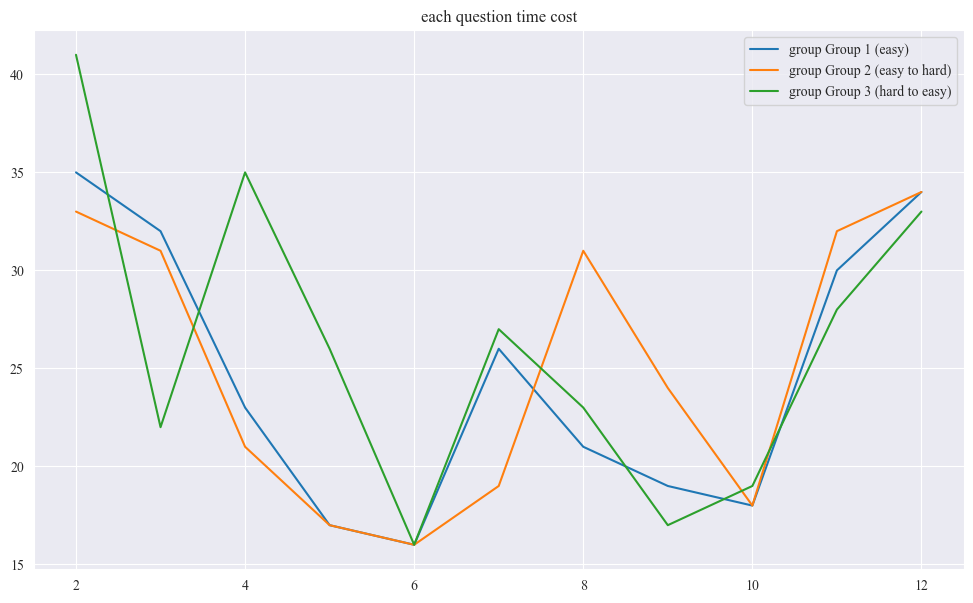

In [93]:
def anstime_analyze(df:pd.DataFrame,groups:list,q_len,col:str):
    results = []
    for group in groups:
        temp = []
        df_g = df.query(f'experiment_mode == {group}')
        matrix = df_g[f'{col}'].values
        for li in matrix:
            temp.append(li[:11])
        results.append(np.nanmedian(temp,axis = 0))
    return results

qtime = anstime_analyze(valid_experiment_data,groups = [0,1,2,3],col = 'delta_time',q_len=12)
# plot results

plt.figure(figsize=(12,7))
for g,lis in zip([1,2,3],qtime[1:4]):
    plt.plot([i+2 for i in range(11)],lis,label = f'group {group_translate[g]}')
plt.title('each question time cost')
plt.legend()



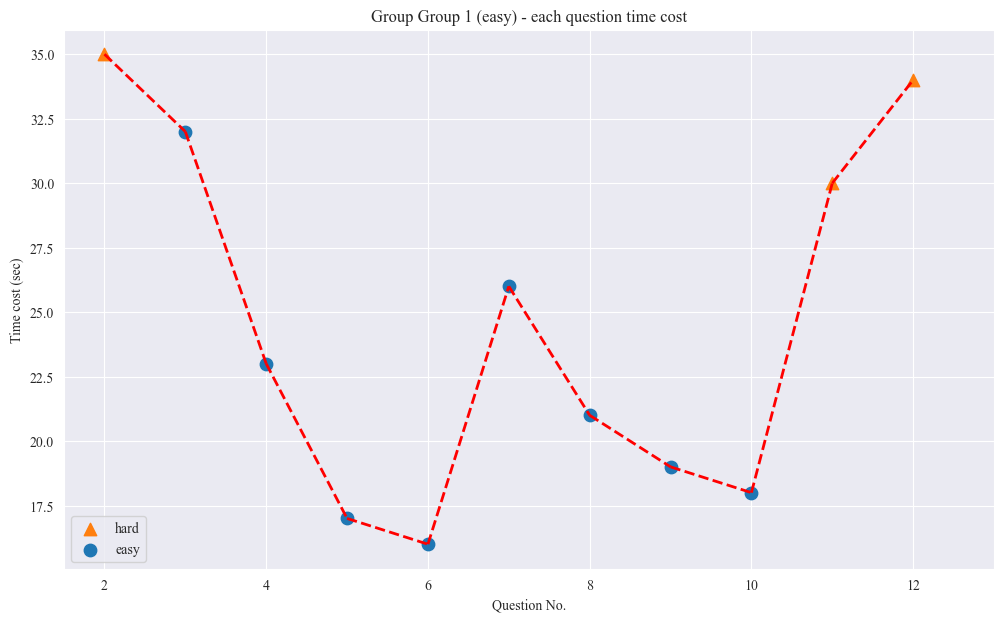

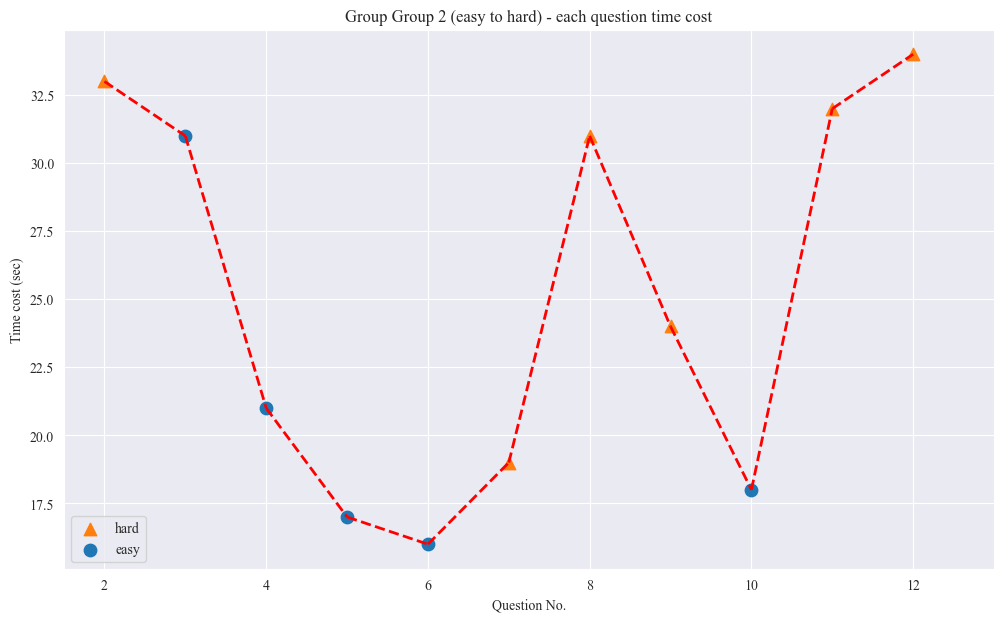

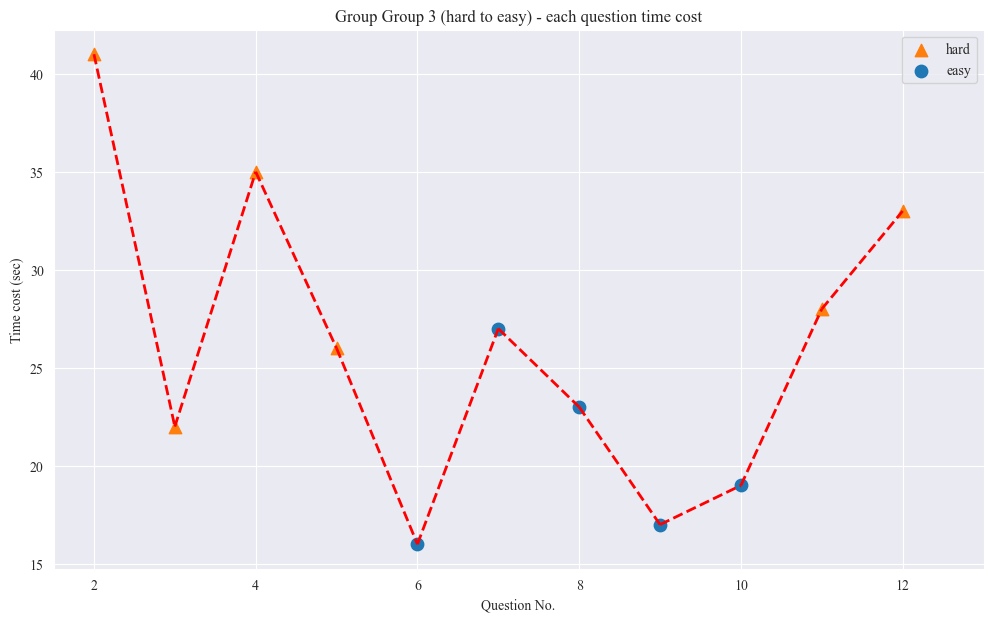

In [94]:
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import numpy as np

# 假資料（假設 qtime 已存在）
# qtime = [None, np.random.rand(12), np.random.rand(12), np.random.rand(12)]
# group_translate = {1: "A", 2: "B", 3: "C"}

marker_seqs = {
    1: ['^', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', '^', '^', '^'],
    2: ['^', 'o', 'o', 'o', 'o', '^', '^', '^', 'o', '^', '^', '^'],
    3: ['^', '^', '^', '^', 'o', 'o', 'o', 'o', 'o', '^', '^', '^']
}

line_color = 'red'  # 紅色線

for g, lis in zip([1, 2, 3], qtime[1:4]):
    x = np.arange(2, 2 + len(lis))
    y = lis

    fig, ax = plt.subplots(figsize=(12, 7))

    # 正確建立線段資料
    points = np.column_stack([x, y])
    segments = np.stack([points[:-1], points[1:]], axis=1)  # (n-1, 2, 2)
    lc = LineCollection(segments, colors=line_color, linewidths=2, linestyles='--')  # 紅色虛線
    ax.add_collection(lc)

    # 畫每個點
    scatter_handles = {}  # 用來避免重複圖例
    for xi, yi, m in zip(x, y, marker_seqs[g]):
        if m == 'o':
            color = 'C0'
            label = 'easy'
        elif m == '^':
            color = 'C1'
            label = 'hard'
        else:
            color = 'black'
            label = None

        sc = ax.scatter(xi, yi, marker=m, color=color, s=80,
                        label=label if label not in scatter_handles else None)
        if label and label not in scatter_handles:
            scatter_handles[label] = sc

    ax.set_title(f'Group {group_translate[g]} - each question time cost')
    ax.set_xlim([1.5, 13])
    ax.legend()
    ax.set_xlabel("Question No.")
    ax.set_ylabel("Time cost (sec)")
    plt.show()


Text(0, 0.5, 'Time cost (sec)')

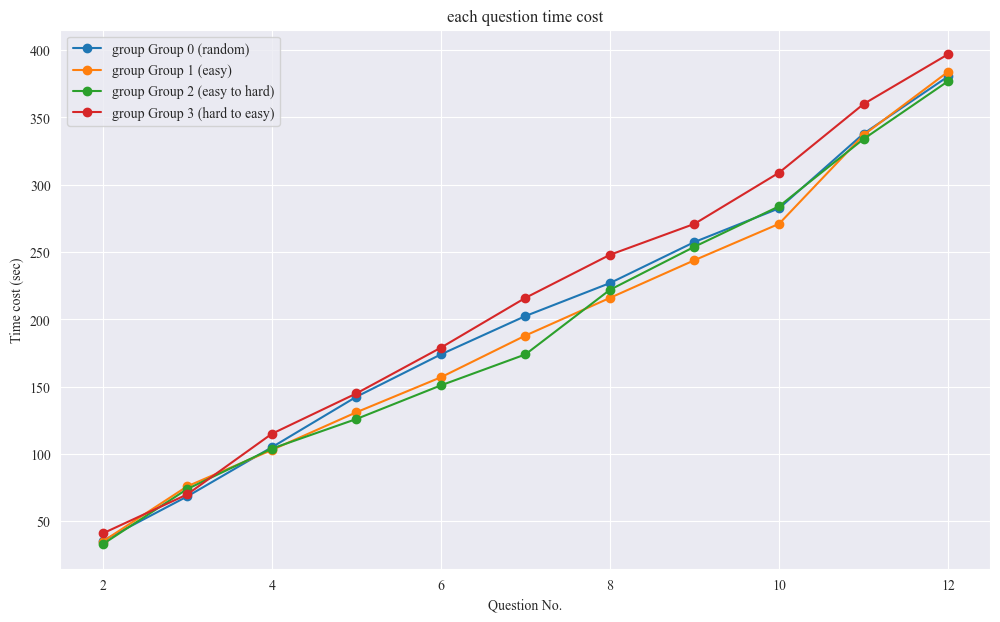

In [95]:
acctime = anstime_analyze(valid_experiment_data,groups = [0,1,2,3],col = 'accumulate_time',q_len=12)

# plot results
plt.figure(figsize=(12,7))
for g,lis in zip([0,1,2,3],acctime):
    plt.plot([i+2 for i in range(11)],lis,label = f'group {group_translate[g]}',marker = "o")
plt.title('each question time cost')
plt.legend()
plt.xlabel('Question No.')
plt.ylabel('Time cost (sec)')

In [96]:
acctime

[array([ 35.5,  68.5, 105. , 142.5, 174. , 202.5, 227. , 257.5, 282.5,
        338. , 380.5]),
 array([ 35.,  76., 103., 131., 157., 188., 216., 244., 271., 337., 384.]),
 array([ 33.,  74., 104., 126., 151., 174., 222., 254., 284., 334., 377.]),
 array([ 41.,  70., 115., 145., 179., 216., 248., 271., 309., 360., 397.])]

In [97]:
# generate ols to estimate the time difference between groups

regdf = valid_experiment_data.query('experiment_mode != 0').copy()
# compare at 6,10,12
for qnum in [5,9,11]:
    regdf[f'_{qnum}_acctime'] = regdf['accumulate_time'].apply(lambda lis:lis[qnum-1])
    regdf['experiment_mode'] = regdf['experiment_mode'].astype(int)
    formula = f'_{qnum}_acctime ~ C(experiment_mode,Treatment(reference=1))'
    model = smf.quantreg(formula=formula,data = regdf).fit(q=0.5)
    print(model.summary())






                         QuantReg Regression Results                          
Dep. Variable:             _5_acctime   Pseudo R-squared:             0.005816
Model:                       QuantReg   Bandwidth:                       50.11
Method:                 Least Squares   Sparsity:                        205.0
Date:                Fri, 19 Sep 2025   No. Observations:                  637
Time:                        10:33:10   Df Residuals:                      634
                                        Df Model:                            2
                                                      coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------
Intercept                                         157.0000      6.686     23.482      0.000     143.871     170.129
C(experiment_mode, Treatment(reference=1))[T.2]    -6.0000      9.770     -0.614      0.539     -25

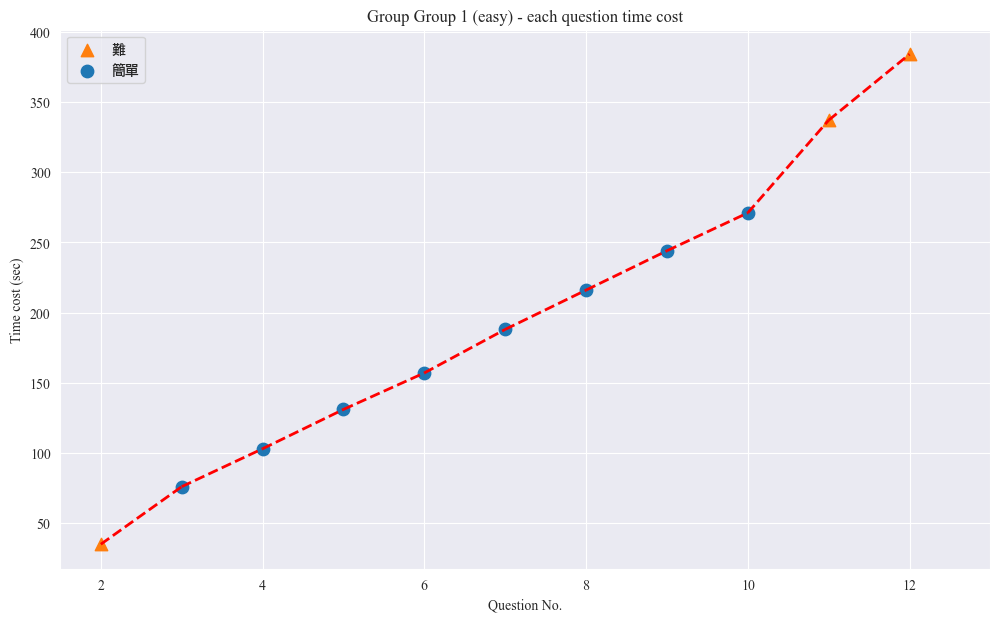

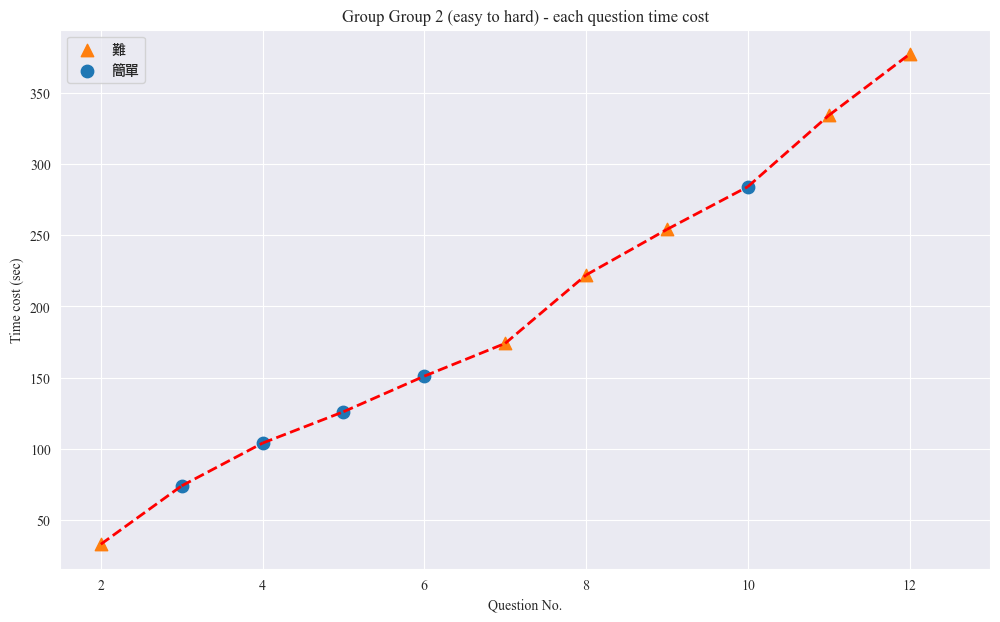

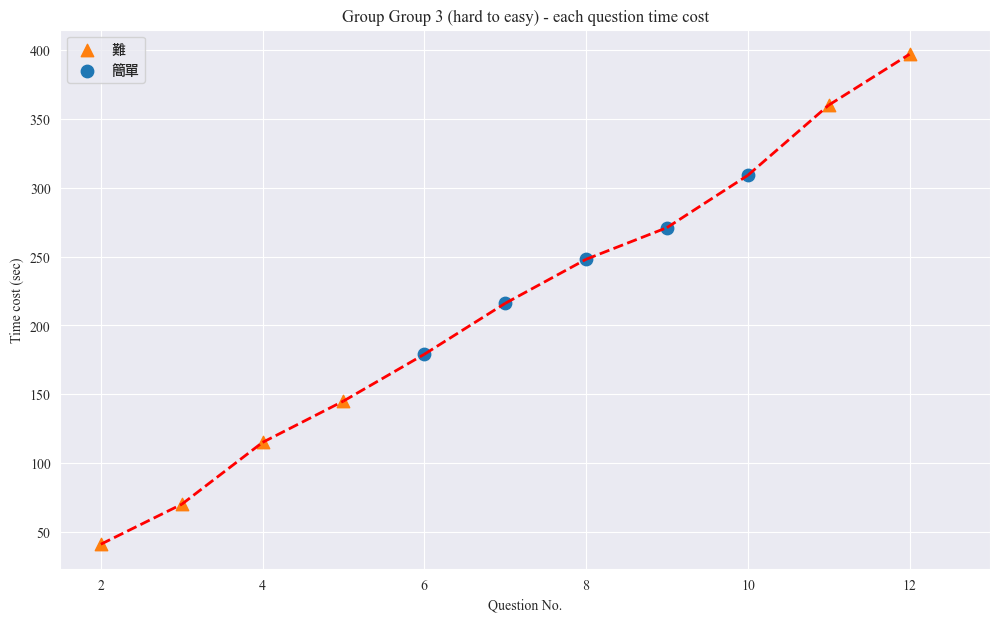

In [98]:
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import numpy as np

# 假資料（假設 qtime 已存在）
# qtime = [None, np.random.rand(12), np.random.rand(12), np.random.rand(12)]
# group_translate = {1: "A", 2: "B", 3: "C"}

marker_seqs = {
    1: ['^', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', '^', '^', '^'],
    2: ['^', 'o', 'o', 'o', 'o', '^', '^', '^', 'o', '^', '^', '^'],
    3: ['^', '^', '^', '^', 'o', 'o', 'o', 'o', 'o', '^', '^', '^']
}

line_color = 'red'  # 紅色線

for g, lis in zip([1, 2, 3], acctime[1:4]):
    x = np.arange(2, 2 + len(lis))
    y = lis

    fig, ax = plt.subplots(figsize=(12, 7))

    # 正確建立線段資料
    points = np.column_stack([x, y])
    segments = np.stack([points[:-1], points[1:]], axis=1)  # (n-1, 2, 2)
    lc = LineCollection(segments, colors=line_color, linewidths=2, linestyles='--')  # 紅色虛線
    ax.add_collection(lc)

    # 畫每個點
    scatter_handles = {}  # 用來避免重複圖例
    for xi, yi, m in zip(x, y, marker_seqs[g]):
        if m == 'o':
            color = 'C0'
            label = '簡單'
        elif m == '^':
            color = 'C1'
            label = '難'
        else:
            color = 'black'
            label = None

        sc = ax.scatter(xi, yi, marker=m, color=color, s=80,
                        label=label if label not in scatter_handles else None)
        if label and label not in scatter_handles:
            scatter_handles[label] = sc

    ax.set_title(f'Group {group_translate[g]} - each question time cost')
    ax.set_xlim([1.5, 13])
    ax.legend()
    ax.set_xlabel("Question No.")
    ax.set_ylabel("Time cost (sec)")
    plt.show()


In [99]:
# quntile regression on qtime 10,11,12
import statsmodels.formula.api as smf


for qn in [10,11,12]:
    data = {'time_cost' : valid_experiment_data['delta_time'].apply(lambda x: x[qn-2]), 'group': valid_experiment_data['experiment_mode']}
    mod = smf.quantreg(f'time_cost ~ C(group,Treatment(reference=1))',data = data)
    res = mod.fit(q = 0.5)
    print(f'\n\n\n----------------------------Q {qn}-------------------------\n\n\n')
    print(res.summary())




----------------------------Q 10-------------------------



                         QuantReg Regression Results                          
Dep. Variable:              time_cost   Pseudo R-squared:            0.0004121
Model:                       QuantReg   Bandwidth:                       5.019
Method:                 Least Squares   Sparsity:                        23.18
Date:                Fri, 19 Sep 2025   No. Observations:                  863
Time:                        10:33:11   Df Residuals:                      859
                                        Df Model:                            3
                                               coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------
Intercept                                   18.0000      0.756     23.804      0.000      16.516      19.484
C(group, Treatment(reference=1))[T.-1.0] -1.779e-16     

/Users/eric/Documents/SchoolCourses/PaGamO/venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/Users/eric/Documents/SchoolCourses/PaGamO/venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/Users/eric/Documents/SchoolCourses/PaGamO/venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


In [100]:
data = {'time_cost' : valid_experiment_data['accumulate_time'].apply(lambda x: x[10]), 'group': valid_experiment_data['experiment_mode']}
mod = smf.quantreg(f'time_cost ~ C(group,Treatment(reference=1))',data = data)
res = mod.fit(q = 0.5)
print(res.summary())

                         QuantReg Regression Results                          
Dep. Variable:              time_cost   Pseudo R-squared:             0.001153
Model:                       QuantReg   Bandwidth:                       106.0
Method:                 Least Squares   Sparsity:                        503.1
Date:                Fri, 19 Sep 2025   No. Observations:                  863
Time:                        10:33:11   Df Residuals:                      859
                                        Df Model:                            3
                                               coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------
Intercept                                  384.0000     16.410     23.401      0.000     351.792     416.208
C(group, Treatment(reference=1))[T.-1.0]   1.72e-14        nan        nan        nan         nan         nan
C(group, Tr

/Users/eric/Documents/SchoolCourses/PaGamO/venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


In [101]:
valid_experiment_data.value_counts('experiment_mode')

experiment_mode
 1.0    235
 0.0    226
 2.0    207
 3.0    195
-1.0      0
Name: count, dtype: int64

x# seq correct analyze

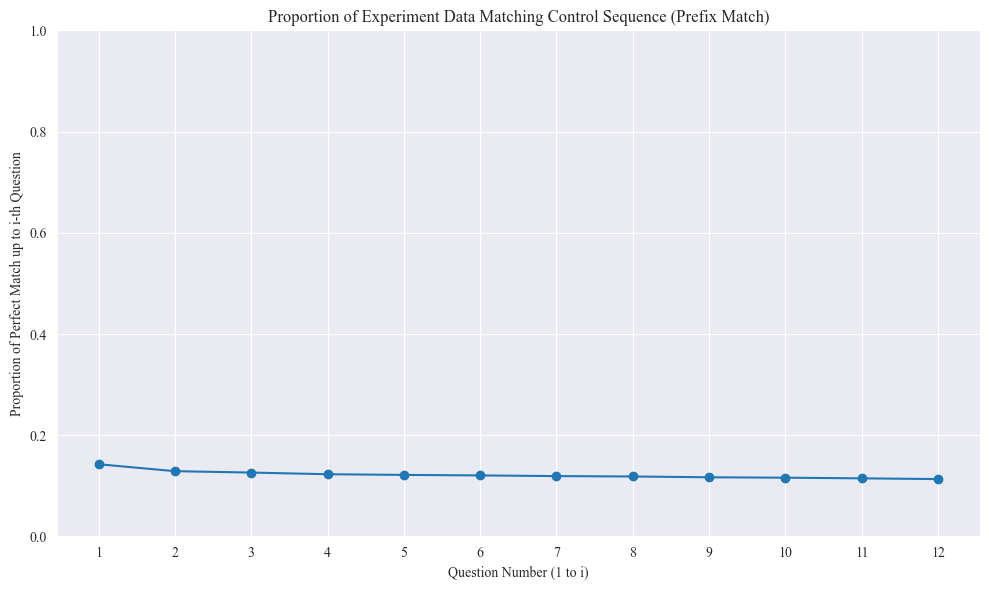

[np.float64(0.14270696452036793), np.float64(0.1290407358738502), np.float64(0.12628120893561104), np.float64(0.12299605781865966), np.float64(0.12168199737187911), np.float64(0.12063074901445467), np.float64(0.1193166885676741), np.float64(0.11852825229960579), np.float64(0.11695137976346912), np.float64(0.1161629434954008), np.float64(0.11484888304862023), np.float64(0.11340341655716163)]


In [102]:
import matplotlib.pyplot as plt

# 確保有以下變數
# experiment_data: dataframe，含欄位 '12_question_id', 'search_key'
# seq_dict: dict，key 為 search_key，value 為正確的 sequence（長度 12 的 array）

# 儲存每一題符合比例
match_ratios = []

# 遍歷 1~12 題
for i in range(1, 13):
    def is_prefix_match(row):
        control_seq = seq_dict.get(row['search_key'])
        if control_seq is None:
            return False
        return np.array_equal(row['12_question_id'][:i], control_seq[:i])

    matched = experiment_data.apply(is_prefix_match, axis=1)
    ratio = matched.mean()  # 符合者比例
    match_ratios.append(ratio)

# 畫圖
plt.figure(figsize=(10, 6))
plt.plot(range(1, 13), match_ratios, marker='o', linestyle='-')
plt.xticks(range(1, 13))
plt.xlabel('Question Number (1 to i)')
plt.ylabel('Proportion of Perfect Match up to i-th Question')
plt.title('Proportion of Experiment Data Matching Control Sequence (Prefix Match)')
plt.grid(True)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()
print(match_ratios)

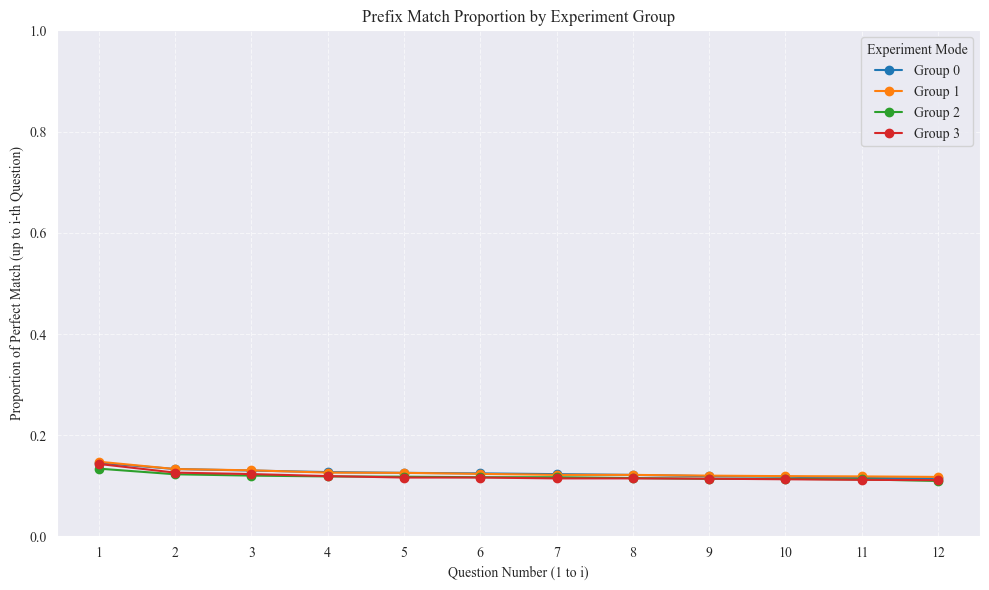

In [103]:
import matplotlib.pyplot as plt

# 取得實驗組別（排除 -1）
experiment_groups = experiment_data['experiment_mode'].unique()
experiment_groups = sorted([int(g) for g in experiment_groups if g != -1])

# 建立 dict 儲存每組比例序列
group_match_ratios = {g: [] for g in experiment_groups}

for i in range(1, 13):  # 題號 1~12
    for g in experiment_groups:
        df_g = experiment_data[experiment_data['experiment_mode'] == g]
        def is_prefix_match(row):
            control_seq = seq_dict.get(row['search_key'])
            if control_seq is None:
                return False
            return np.array_equal(row['12_question_id'][:i], control_seq[:i])
        matched = df_g.apply(is_prefix_match, axis=1)
        ratio = matched.mean()
        group_match_ratios[g].append(ratio)

# 畫圖
plt.figure(figsize=(10, 6))
x = range(1, 13)
for g in experiment_groups:
    plt.plot(x, group_match_ratios[g], marker='o', label=f'Group {g}')

plt.xticks(x)
plt.xlabel('Question Number (1 to i)')
plt.ylabel('Proportion of Perfect Match (up to i-th Question)')
plt.title('Prefix Match Proportion by Experiment Group')
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(0, 1)
plt.legend(title='Experiment Mode')
plt.tight_layout()
plt.show()


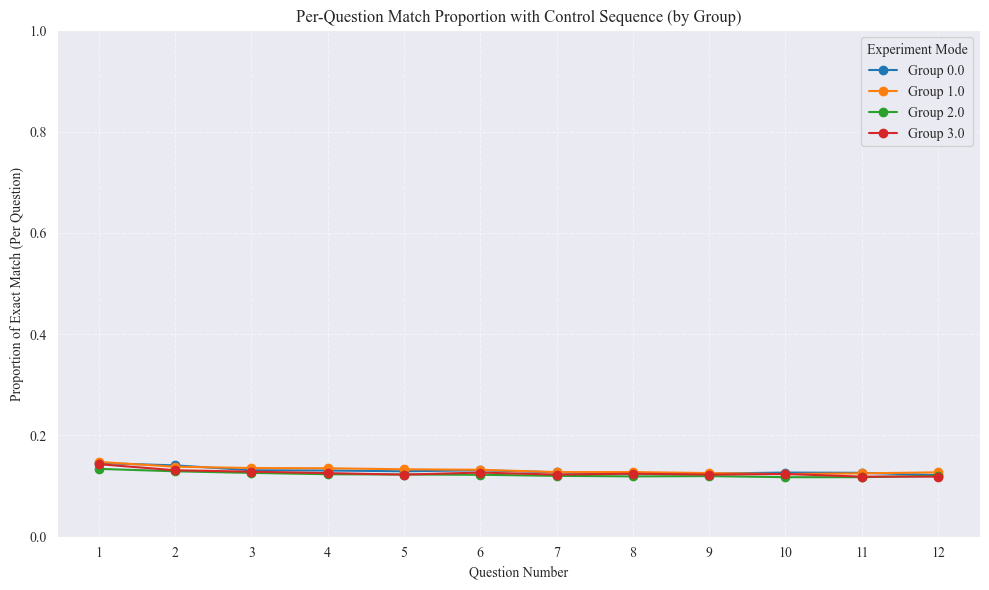

In [104]:
import matplotlib.pyplot as plt

# 設定組別（可依實際資料而定）
experiment_groups = sorted(experiment_data['experiment_mode'].dropna().unique())

# 儲存各組別在每一題的符合比例
group_question_match = {g: [] for g in experiment_groups}

# 對每一題 (0-indexed for Python)
for i in range(12):  # 題號 1~12
    for g in experiment_groups:
        df_g = experiment_data[experiment_data['experiment_mode'] == g]

        def is_q_match(row):
            control_seq = seq_dict.get(row['search_key'])
            if control_seq is None:
                return False
            return row['12_question_id'][i] == control_seq[i]

        matched = df_g.apply(is_q_match, axis=1)
        match_ratio = matched.mean()
        group_question_match[g].append(match_ratio)

# 畫圖
plt.figure(figsize=(10, 6))
x = list(range(1, 13))  # 題號

for g in experiment_groups:
    plt.plot(x, group_question_match[g], marker='o', label=f'Group {g}')

plt.xticks(x)
plt.xlabel('Question Number')
plt.ylabel('Proportion of Exact Match (Per Question)')
plt.title('Per-Question Match Proportion with Control Sequence (by Group)')
plt.ylim(0, 1)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Experiment Mode')
plt.tight_layout()
plt.show()


In [105]:
print(experiment_data.count())
print(experiment_data.seq_valid.value_counts())

user_id                 7610
session_id              7610
gamecharacter_id        7610
section_id              7610
difficulty_level        7610
is_correct              7610
question_id             7610
experiment_index        7610
experiment_mode         7610
create_time             7610
start at                7610
end at                  7610
average correct rate    7610
question length         7610
time cost               7610
q_len                   7610
create_at               7610
q_1                     7610
q_1_corr                7610
q_2                     7610
q_2_corr                7610
q_3                     7610
q_3_corr                7610
q_4                     7610
q_4_corr                7610
q_5                     7610
q_5_corr                7610
q_6                     7610
q_6_corr                7610
q_7                     7610
q_7_corr                7610
q_8                     7610
q_8_corr                7610
q_9                     7610
q_9_corr      

In [106]:
exp_long = long_data[long_data['experiment_mode'].isin([0,1,2,3])]
non_exp_long = long_data[~long_data['experiment_mode'].isin([0,1,2,3])]

In [107]:
long_data[long_data['section_id'] == -9042528178512436726][['experiment_mode','question_id','create_time']]

,experiment_mode,question_id,create_time
2,1.0,"[4680614589130178593, -1794677401750382001, -1...","[2025-04-14 02:15:35, 2025-04-14 02:16:33, 202..."
44,1.0,"[4680614589130178593, -1794677401750382001, -1...","[2025-04-29 18:55:30, 2025-04-29 18:56:22, 202..."
47,1.0,"[-4116423149043926709, -4592512218980948806, 1...","[2025-04-29 21:27:53, 2025-04-29 21:29:18, 202..."
61,1.0,"[4680614589130178593, -1794677401750382001, -1...","[2025-04-30 09:07:45, 2025-04-30 09:09:02, 202..."
267,1.0,"[-6000192930553518111, 4680614589130178593, 68...","[2025-02-24 15:00:49, 2025-02-24 15:00:59, 202..."
...,...,...,...
83718,0.0,"[5965471197004972849, 253304982378290942, 6728...","[2025-04-08 09:05:34, 2025-04-08 09:06:03, 202..."
83720,0.0,"[4680614589130178593, -7934014245957245064, -3...","[2025-04-29 09:13:42, 2025-04-29 09:14:27, 202..."
83730,-1.0,"[-5077585123232575398, 3847776141460785270, 55...","[2025-03-25 12:32:01, 2025-03-25 12:32:20, 202..."
83731,-1.0,"[-4592512218980948806, 6728580364155644856, -2...","[2025-03-27 12:34:58, 2025-03-27 12:35:11, 202..."


In [108]:
control_seqs

,Unnamed: 0,sequence,publisher,section_name,book_volume_name,publisher_name_113_2,section_name_113_2,book_volume_name_113_2,Q1,Q2,...,Q7,Q8,Q9,Q10,Q11,Q12,section_id,experiment_mode,search_key,control_seq
0,0,control,康軒國小,3 容積,五下112,康軒國小,3 容積,五下113,69113588992878618,-75308616834142435,...,-1908360932417219092,-2348804092072956357,4649250512404957905,5948577754904052468,-4358907609513604648,-7361052562344121223,-3545039493898610459,0,-3545039493898610459_0,"[69113588992878618, -75308616834142435, -53711..."
1,1,treatment1,康軒國小,3 容積,五下112,康軒國小,3 容積,五下113,69113588992878618,-75308616834142435,...,4334620487126035177,5108527915460688310,-1288720951380365417,5948577754904052468,-4358907609513604648,-7361052562344121223,-3545039493898610459,1,-3545039493898610459_1,"[69113588992878618, -75308616834142435, -23488..."
2,2,treatment2,康軒國小,3 容積,五下112,康軒國小,3 容積,五下113,69113588992878618,-75308616834142435,...,-3202230148646485972,-1908360932417219092,-8594155001789108421,5948577754904052468,-4358907609513604648,-7361052562344121223,-3545039493898610459,2,-3545039493898610459_2,"[69113588992878618, -75308616834142435, -23488..."
3,3,treatment3,康軒國小,3 容積,五下112,康軒國小,3 容積,五下113,69113588992878618,-75308616834142435,...,-2348804092072956357,-5371107019222777434,4649250512404957905,5948577754904052468,-4358907609513604648,-7361052562344121223,-3545039493898610459,3,-3545039493898610459_3,"[69113588992878618, -75308616834142435, -32022..."
4,0,control,康軒國小,9 時間的乘除,五下112,康軒國小,9 時間的乘除,五下113,520497830035904533,-2091250926218676150,...,-2307309825203258326,-4398838213214723618,4054464459422027015,2596504183669148612,3305360628776648069,-2670908083034426001,-3525338262485141936,0,-3525338262485141936_0,"[520497830035904533, -2091250926218676150, 174..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,3,treatment3,康軒國小,5 十進位結構,五下112,康軒國小,5 十進位結構,五下113,4680614589130178593,-1794677401750382001,...,-1113156898056861262,3847776141460785270,-3678348170036989128,1637307589124347792,5581172194395314614,8231509399365486276,-9042528178512436726,3,-9042528178512436726_3,"[4680614589130178593, -1794677401750382001, -6..."
60,0,control,康軒國小,1 體積,五下112,康軒國小,1 體積,五下113,5986642740406154097,-1814475752912975980,...,4816520945223989067,7246391716930387719,5709007776101919275,8707461698589525409,831253084160088526,-5263639425820740356,-247801341597882458,0,-247801341597882458_0,"[5986642740406154097, -1814475752912975980, 57..."
61,1,treatment1,康軒國小,1 體積,五下112,康軒國小,1 體積,五下113,5986642740406154097,-1814475752912975980,...,-9013829383219240211,5556066601331488933,-3286862775113972652,8707461698589525409,831253084160088526,-5263639425820740356,-247801341597882458,1,-247801341597882458_1,"[5986642740406154097, -1814475752912975980, 57..."
62,2,treatment2,康軒國小,1 體積,五下112,康軒國小,1 體積,五下113,5986642740406154097,-1814475752912975980,...,4816520945223989067,-1025311054463154271,7479955377401805758,8707461698589525409,831253084160088526,-5263639425820740356,-247801341597882458,2,-247801341597882458_2,"[5986642740406154097, -1814475752912975980, 57..."
